# Diabetes Risk Prediction

## Objective
The goal of this project is to predict the **risk of diabetes** based on patient data, including demographics, medical history, and lifestyle factors.

## Dataset Overview
The dataset contains records of individuals with features relevant to diabetes risk assessment.

## Instructions
1. **Data Exploration**: Load and examine the dataset.
2. **Data Preprocessing**: Handle missing values, encode categorical variables, and normalize numerical features and visualization graph amd distribution by category.

In [2]:

# Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:

# Load the dataset
df = pd.read_csv('framingham.csv')
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)
df.head()

# Display basic information about the dataset


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


## Exploratory Data Analysis (EDA)
- Check for missing values
- Visualize key distributions
- Identify correlations between features

In [4]:
#summary 
df.info()

# Check for missing values

df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

# Visualize Key Distributions

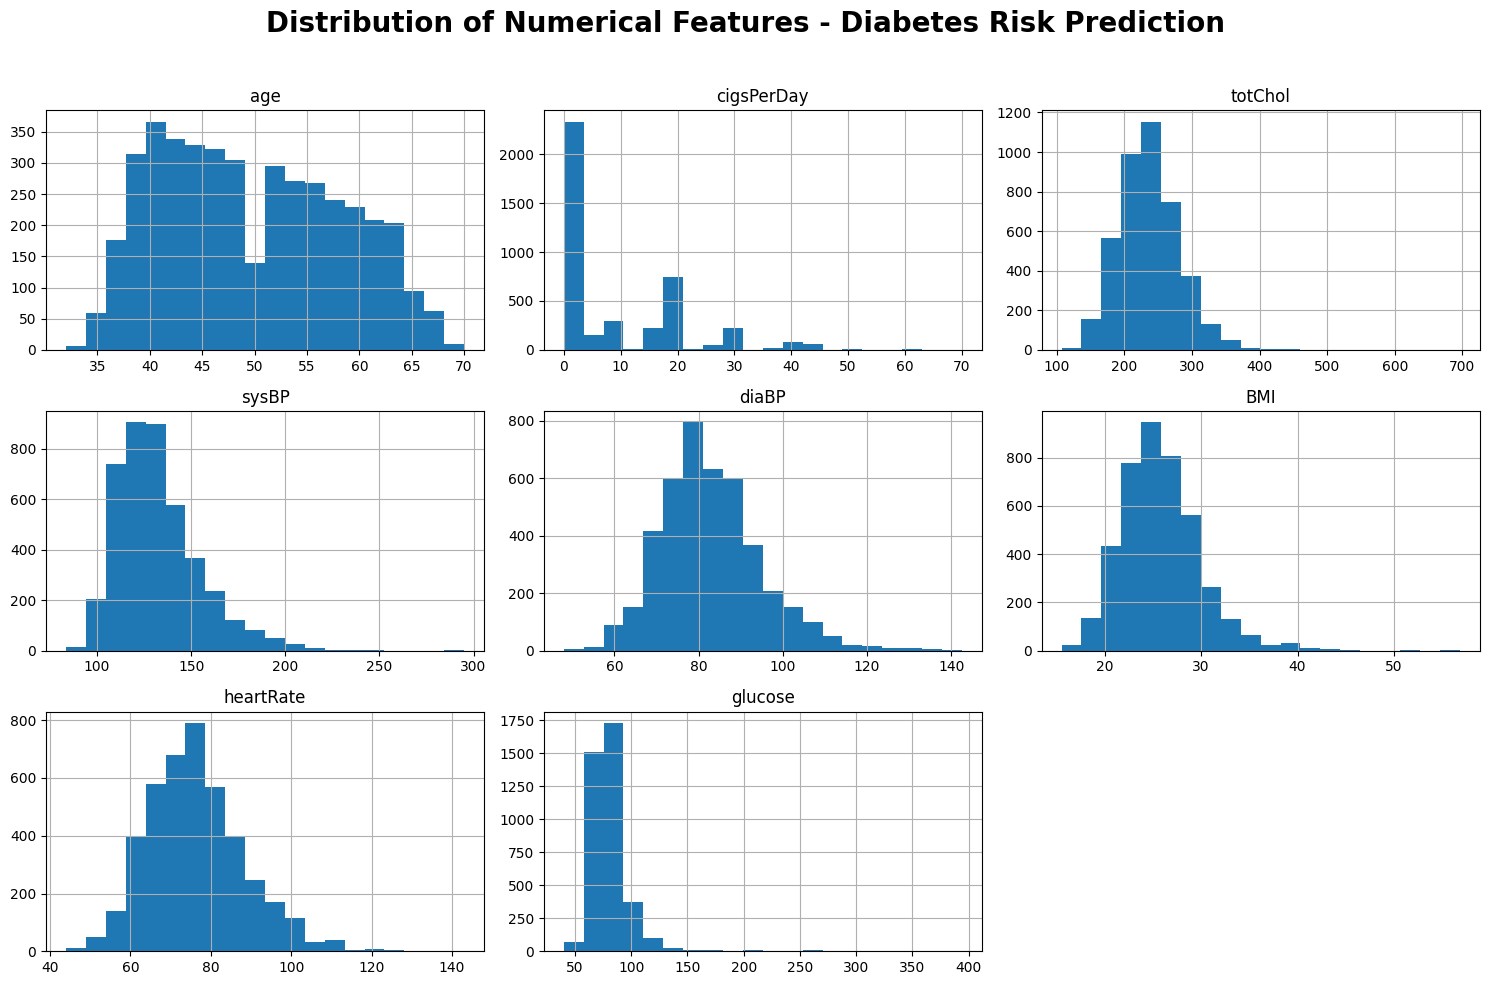

In [5]:

numerical_cols = [
    "age","cigsPerDay","totChol","sysBP",
    "diaBP","BMI","heartRate","glucose"
]

df[numerical_cols].hist(figsize=(15,10), bins=20)
plt.suptitle("Distribution of Numerical Features - Diabetes Risk Prediction",fontsize=20,fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Identify Correlations Between Features

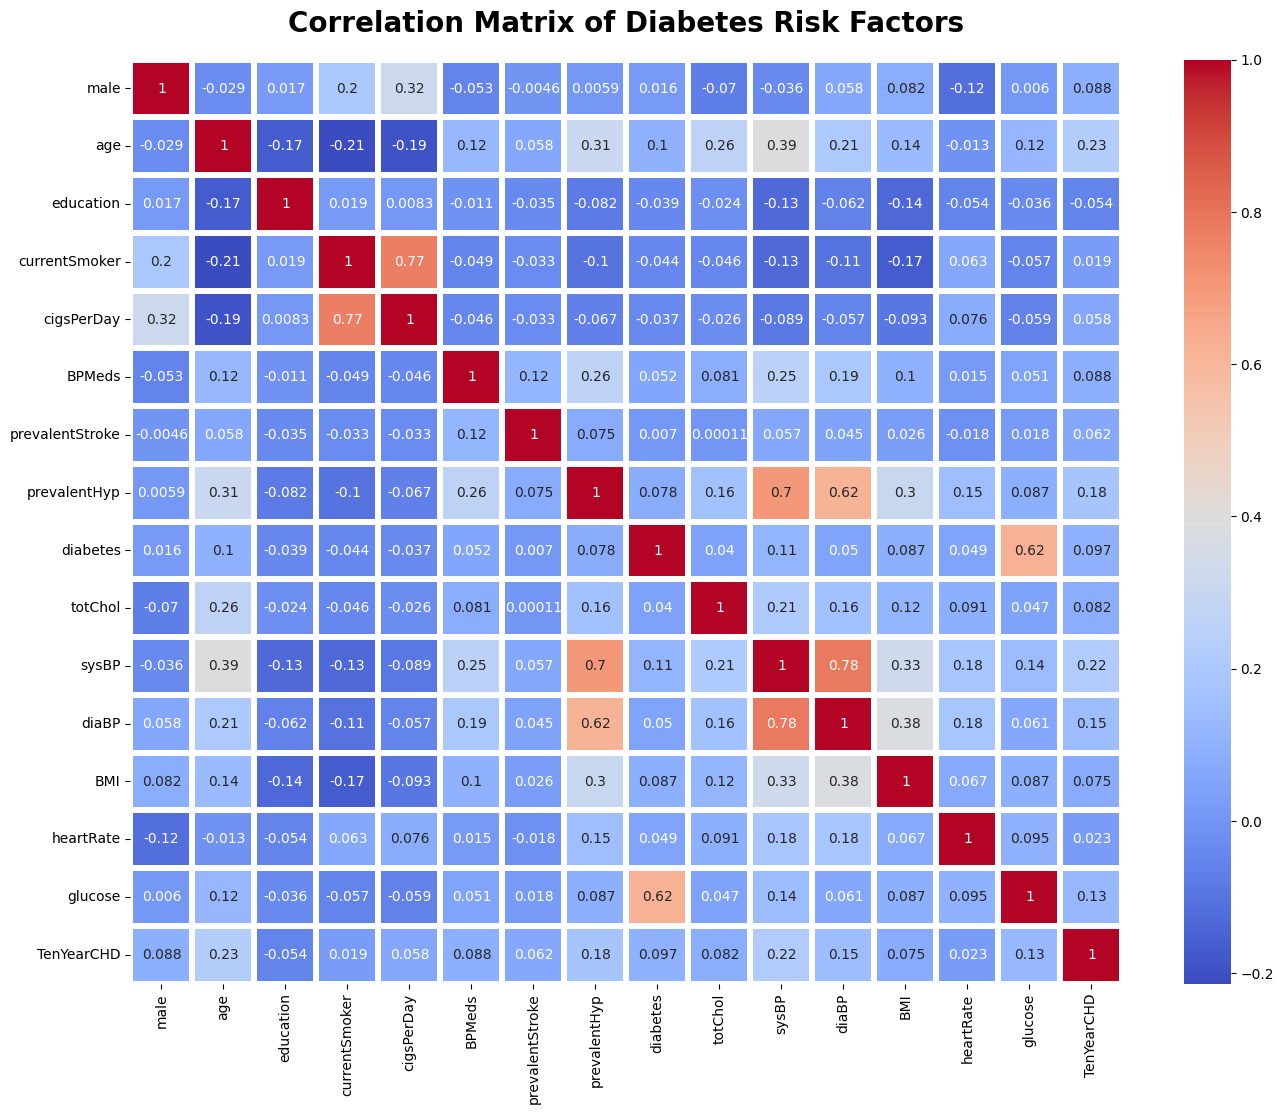

In [6]:
plt.figure(figsize=(16,12))
sns.heatmap(df.corr(numeric_only=True), annot=True, linewidth = 4, cmap="coolwarm")
plt.title("Correlation Matrix of Diabetes Risk Factors",fontsize=20,fontweight="bold",pad=20)
plt.show()

## Data Preprocessing
- Handle missing values
- Encode categorical variables
- Normalize numerical features

In [7]:
df["education"] = df["education"].fillna(df["education"].mode()[0])
df["cigsPerDay"] = df["cigsPerDay"].fillna(df["cigsPerDay"].median())
df["BPMeds"] = df["BPMeds"].fillna(df["BPMeds"].mode()[0])
df["totChol"] = df["totChol"].fillna(df["totChol"].median())
df["BMI"] = df["BMI"].fillna(df["BMI"].median())
df["heartRate"] = df["heartRate"].fillna(df["heartRate"].median())
df["glucose"] = df["glucose"].fillna(df["glucose"].median())

In [8]:
df.isna().sum()

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64

In [9]:
df.rename(columns={"male":"gender"},inplace=True)

In [11]:
df["gender_category"] = np.select(
    [
       df["gender"] == 0,
       df["gender"] == 1
    ],
    [
        "Male",
        "Female"
    ],
    default = "Unknow"
)

In [12]:
df["gender_category"].value_counts(dropna=False)

gender_category
Male      2420
Female    1820
Name: count, dtype: int64

# Gender Distribution

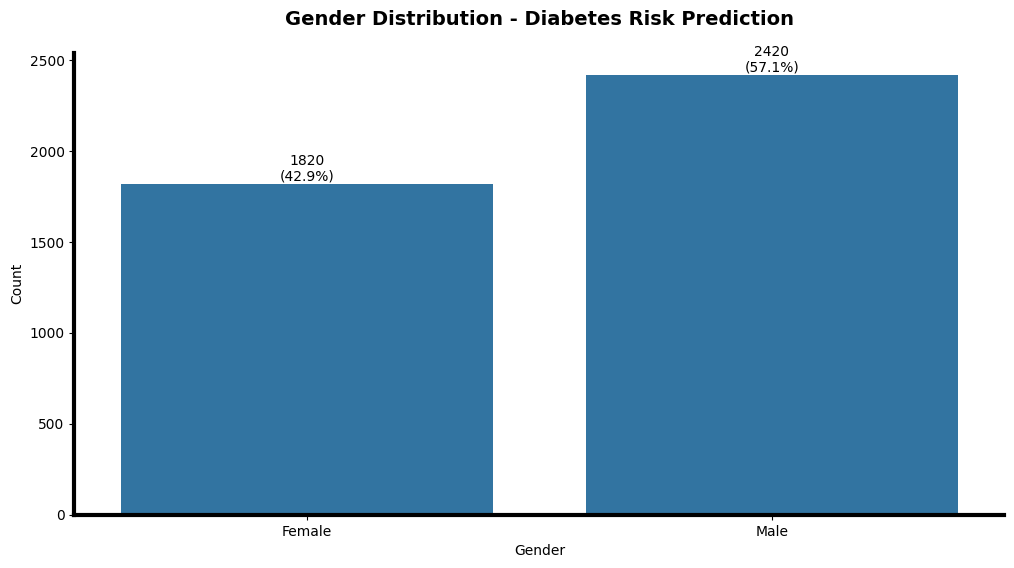

In [13]:
#Distributions
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "gender_category"
)

total = len(df)

for container in ax.containers:
    labels = [f"{v.get_height():.0f}\n({v.get_height()/total*100:.1f}%)" 
              for v in container]
    ax.bar_label(container, labels=labels)

for spine in ax.spines.values():
    spine.set_color("black")
    spine.set_linewidth(3)

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("Gender Distribution - Diabetes Risk Prediction", fontsize=14,pad = 20, fontweight = "bold", color = "black")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

In [35]:
#df["education"].value_counts(dropna=False)

# education_category distribution

In [15]:
df["education_category"] = np.select(
    [
       df["education"] == 1,
       df["education"] == 2,
       df["education"] == 3,
       df["education"] == 4 
    ],
    [
        "Secondary School",
        "Senior Secondary School",
        "Graduate",
        "Postgraduate"
    ],
    default="Unknown"
)

In [16]:
df["education_category"].value_counts(dropna=False)

education_category
Secondary School           1825
Senior Secondary School    1253
Graduate                    689
Postgraduate                473
Name: count, dtype: int64

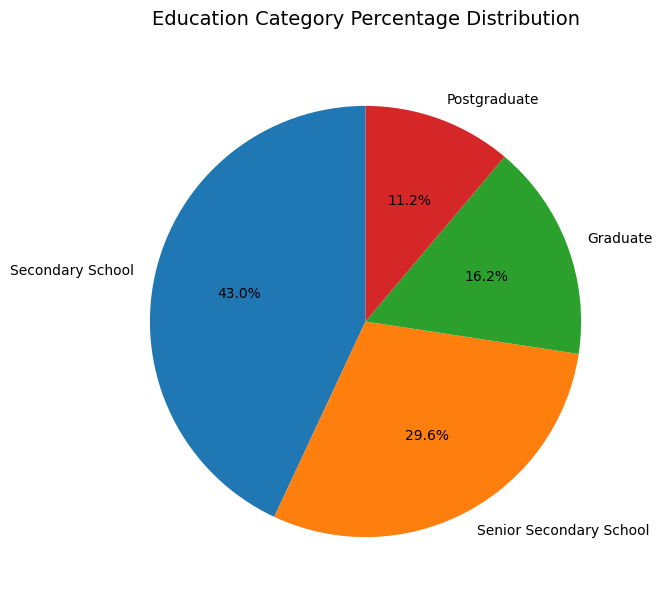

In [17]:
plt.figure(figsize=(7,7))

df["education_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "Education Category Percentage Distribution",
    fontsize=14,
    pad=20
)

plt.ylabel("")
plt.show()

In [83]:
df["cigsPerDay"].unique()

array([ 0., 20., 30., 23., 15.,  9., 10.,  5., 35., 43.,  1., 40.,  3.,
        2., 12.,  4., 18., 25., 60., 14., 45.,  8., 50., 13., 11.,  7.,
        6., 38., 29., 17., 16., 19., 70.])

# Smoking_Category

In [19]:
df["Smoking_Category"] = np.select(
    [
        df["cigsPerDay"] == 0,
        df["cigsPerDay"].between(1,10),
        df["cigsPerDay"].between(11,20),
        df["cigsPerDay"].between(21,39),
        df["cigsPerDay"] >= 40
    ],
    [
        "Non-Smoker",
        "Light Smoker",
        "Moderate Smoker",
        "Heavy Smoker",
        "Very Heavy Smoker"
    ],
    default="Not Reported"
)

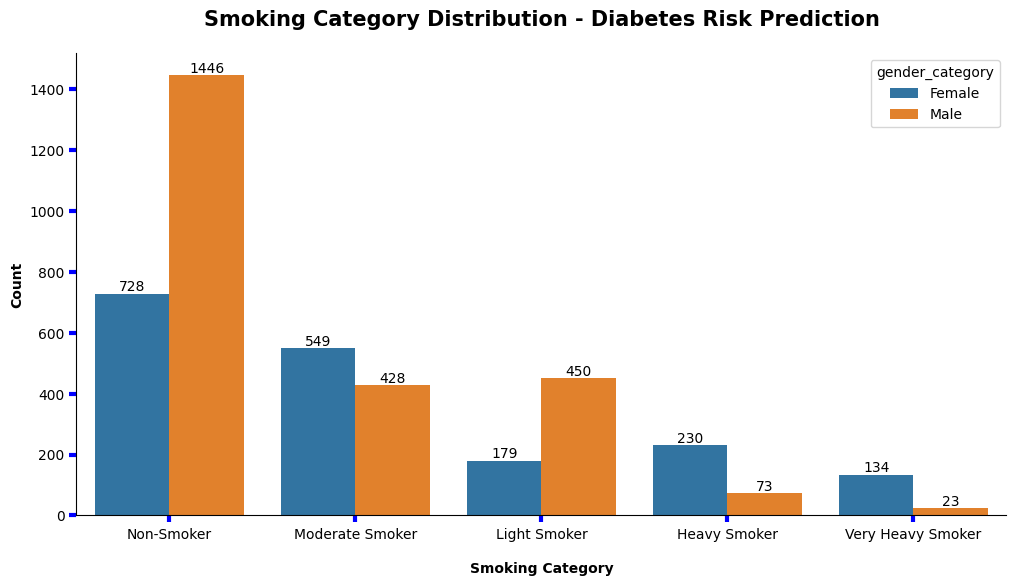

In [20]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "Smoking_Category",
    order = df["Smoking_Category"].value_counts().index,
    hue = "gender_category"
)

for container in ax.containers:
    ax.bar_label(container)

ax.spines['top'].set_visible(False)  
ax.spines['right'].set_visible(False)

ax.tick_params(axis="both",color = 'blue', length = 5, width = 3)

plt.title("Smoking Category Distribution - Diabetes Risk Prediction",fontweight = 'bold', fontsize = 15,pad = 20)
plt.xlabel("Smoking Category",labelpad=15, fontweight = "bold")
plt.ylabel("Count",fontweight = "bold")
plt.show()

In [21]:
(pd.crosstab(
    df["Smoking_Category"],
    df["gender_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

gender_category,Female,Male
Smoking_Category,,
Heavy Smoker,12.64%,3.02%
Light Smoker,9.84%,18.6%
Moderate Smoker,30.16%,17.69%
Non-Smoker,40.0%,59.75%
Very Heavy Smoker,7.36%,0.95%


In [23]:
df.rename(columns={"totChol": "Total_Cholesterol"},inplace=True)

 # Cholesterol_Category

In [24]:
df["Cholesterol_Category"] = np.select(
    [
        df["Total_Cholesterol"] <= 200,
        df["Total_Cholesterol"].between(201, 239),
        df["Total_Cholesterol"].between(240, 279),
        df["Total_Cholesterol"].between(280, 399),
        df["Total_Cholesterol"] >= 400
    ],
    [
        "Normal",
        "Borderline High",
        "High",
        "Very High",
        "Critically High"
    ],
    default="Not Reported"
)

In [25]:
df["Cholesterol_Category"].value_counts(dropna=False)

Cholesterol_Category
Borderline High    1472
High               1225
Normal              887
Very High           646
Critically High      10
Name: count, dtype: int64

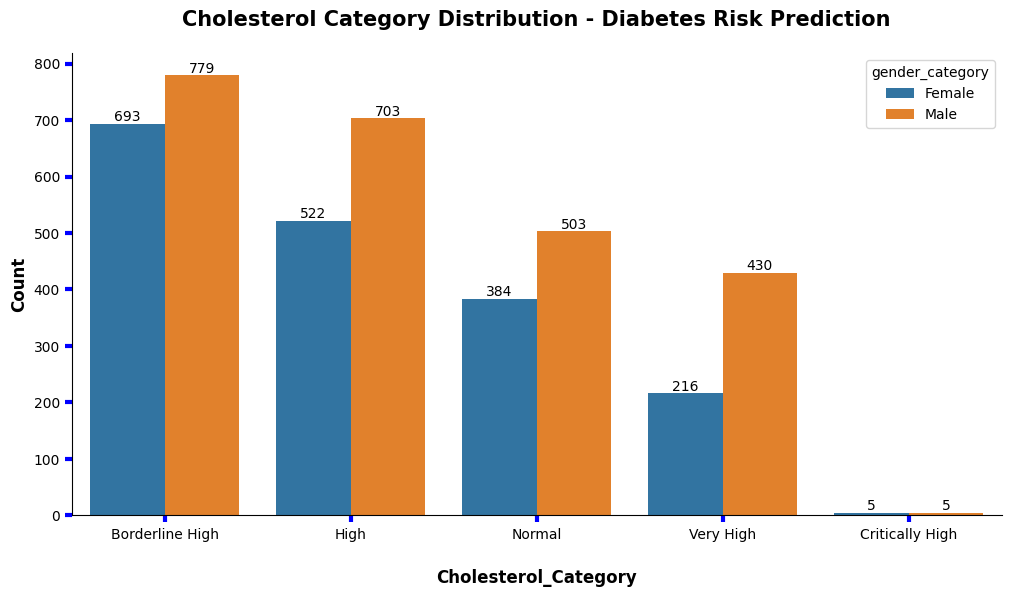

In [26]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "Cholesterol_Category",
    order=(df["Cholesterol_Category"].value_counts().index),
    hue = "gender_category"
)

for container in ax.containers:
    ax.bar_label(container)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis="both",color = 'blue',length = 5, width = 3)

plt.title("Cholesterol Category Distribution - Diabetes Risk Prediction", fontweight = 'bold', fontsize = 15, color = "black", pad = 20)
plt.xlabel("Cholesterol_Category", fontweight = 'bold', fontsize = 12, color = "black", labelpad = 20)
plt.ylabel("Count", fontweight = 'bold', fontsize = 12, color = "black")
plt.show()

In [193]:
(pd.crosstab(
    df["Cholesterol_Category"],
    df["gender_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

gender_category,Female,Male
Cholesterol_Category,,
Borderline High,38.08%,32.19%
Critically High,0.27%,0.21%
High,28.68%,29.05%
Normal,21.1%,20.79%
Very High,11.87%,17.77%


In [138]:
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay',
       'Blood Pressure Medications', 'prevalentStroke', 'prevalentHyp',
       'diabetes', 'Total_Cholesterol', 'sysBP', 'diaBP', 'BMI', 'heartRate',
       'glucose', 'TenYearCHD', 'gender_category', 'education_category',
       'Smoking_Category', 'Cholesterol_Category', 'diabetes_category'],
      dtype='object')

In [136]:
df["diabetes_category"] = np.select(
    [
        df["diabetes"] == 0,
        df["diabetes"] == 1
    ],
    [
        "No Diabetes",
        "Diabetes"
    ],
    default = "Unknow"
)

In [137]:
df["diabetes_category"].unique()

array(['No Diabetes', 'Diabetes'], dtype=object)

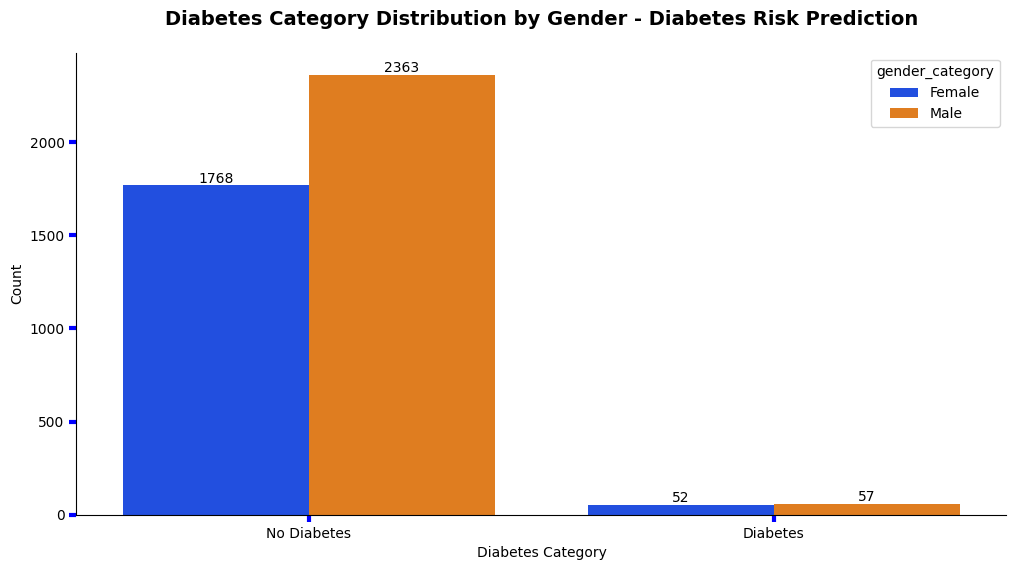

In [153]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "diabetes_category",
    hue = "gender_category",
    palette = "bright"
)

for container in ax.containers:
    ax.bar_label(container)

ax.spines["top"].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis="both",length = 5, width = 3, color = "blue")

plt.title("Diabetes Category Distribution by Gender - Diabetes Risk Prediction",fontsize=14,pad=20,fontweight = "bold")
plt.xlabel("Diabetes Category")
plt.ylabel("Count")
plt.show()

In [190]:
(pd.crosstab(
    df["diabetes_category"],
    df["gender_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

gender_category,Female,Male
diabetes_category,,
Diabetes,2.86%,2.36%
No Diabetes,97.14%,97.64%


In [102]:
df.rename(columns={"BPMeds" : "Blood Pressure Medications"},inplace = True)

In [135]:
df["Blood Pressure Medications"].unique()

array([0., 1.])

In [154]:
df.rename(columns={"sysBP" : "Systolic_BP"},inplace=True)

In [155]:
df["Systolic_BP"].unique()

array([106. , 121. , 127.5, 150. , 130. , 180. , 138. , 100. , 141.5,
       162. , 133. , 131. , 142. , 124. , 114. , 140. , 112. , 122. ,
       139. , 108. , 123.5, 148. , 132. , 137.5, 102. , 110. , 182. ,
       115. , 134. , 147. , 124.5, 153.5, 160. , 153. , 111. , 116.5,
       206. ,  96. , 179.5, 119. , 116. , 156.5, 145. , 143.5, 158. ,
       157. , 126.5, 136. , 154. , 190. , 107. , 112.5, 164.5, 138.5,
       155. , 151. , 152. , 179. , 113. , 200. , 132.5, 126. , 123. ,
       141. , 135. , 187. , 127. , 160.5, 105. , 109. , 128. , 118. ,
       109.5, 117.5, 149. , 180.5, 136.5, 212. , 125. , 191. , 121.5,
       173. , 144. , 129.5, 117. , 144.5, 170. , 137. ,  94. , 119.5,
       143. , 166. , 139.5, 177.5, 129. , 159. , 130.5, 107.5, 189. ,
       168. , 197.5, 146. , 174. , 122.5,  98. , 131.5, 195. , 101. ,
       158.5,  97. , 151.5,  97.5, 120. , 204. , 157.5, 140.5, 171. ,
       215. ,  95. , 156. , 165. , 178. , 146.5, 113.5, 188. , 197. ,
        90. , 152.5,

In [166]:
df["Systolic_BP_Category"] = np.select(
    [
        df["Systolic_BP"] < 120,
        (df["Systolic_BP"] >= 120) & (df["Systolic_BP"] < 140),
        (df["Systolic_BP"] >= 140) & (df["Systolic_BP"] < 160),
        (df["Systolic_BP"] >= 160) & (df["Systolic_BP"] < 180),
        df["Systolic_BP"] >= 180
    ],
    [
        "Normal",
        "Pre-High BP",
        "High BP",
        "Very High BP",
        "Critical BP"
    ],
    default = "unknow"
)

In [167]:
df["Systolic_BP_Category"].value_counts(dropna=False)

Systolic_BP_Category
Pre-High BP     1677
Normal          1279
High BP          806
Very High BP     308
Critical BP      170
Name: count, dtype: int64

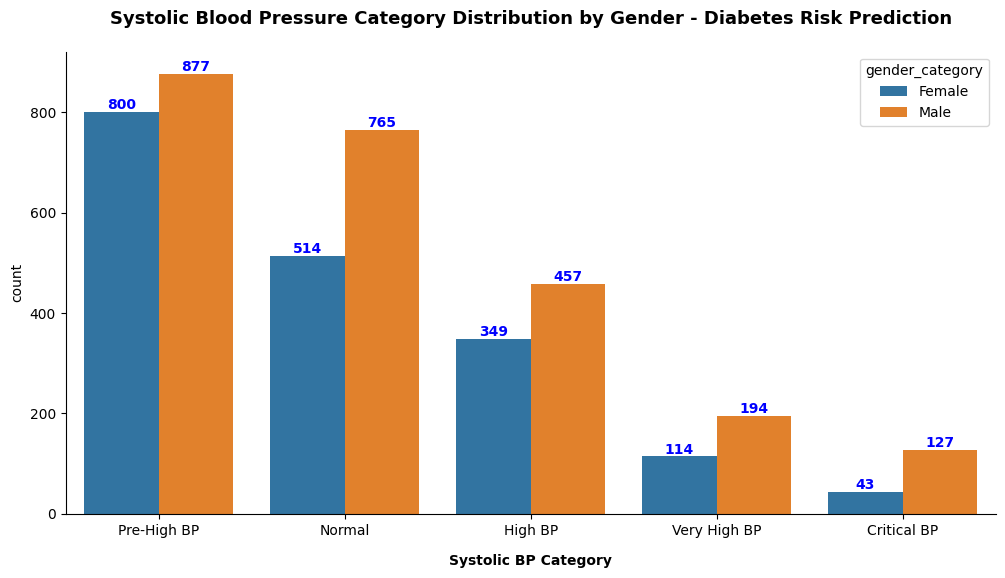

In [185]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "Systolic_BP_Category",
    order = df["Systolic_BP_Category"].value_counts().index,
    hue = "gender_category"
)
for container in ax.containers:
    ax.bar_label(container,fontweight="bold",color = 'blue')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.title("Systolic Blood Pressure Category Distribution by Gender - Diabetes Risk Prediction",fontweight = "bold", 
          fontsize= 13,color = "black",pad = 20)

plt.xlabel("Systolic BP Category",fontweight = "bold",labelpad = 12)
plt.show()

In [189]:
(pd.crosstab(
    df["Systolic_BP_Category"],
    df["gender_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

gender_category,Female,Male
Systolic_BP_Category,,
Critical BP,2.36%,5.25%
High BP,19.18%,18.88%
Normal,28.24%,31.61%
Pre-High BP,43.96%,36.24%
Very High BP,6.26%,8.02%


In [207]:
df.columns

Index(['gender', 'age', 'education', 'currentSmoker', 'cigsPerDay',
       'Blood Pressure Medications', 'prevalentStroke', 'prevalentHyp',
       'diabetes', 'Total_Cholesterol', 'Systolic_BP', 'Diastolic_BP', 'BMI',
       'heartRate', 'glucose', 'TenYearCHD', 'gender_category',
       'education_category', 'Smoking_Category', 'Cholesterol_Category',
       'diabetes_category', 'Systolic_BP_Category', 'HeartRate_Category',
       'BMI_Category', 'Glucose_Category', 'Diastolic_BP_Category'],
      dtype='object')

In [204]:
df.rename(columns={"diaBP": "Diastolic_BP"}, inplace=True)

In [53]:
#df["Diastolic_BP"].unique()

In [205]:
df["Diastolic_BP_Category"] = np.select(
    [
        df["Diastolic_BP"] < 80,
        (df["Diastolic_BP"] >= 80) & (df["Diastolic_BP"] < 90),
        (df["Diastolic_BP"] >= 90) & (df["Diastolic_BP"] < 120),
        df["Diastolic_BP"] >= 120
    ],
    [
        "Normal",
        "Elevated",
        "Hypertension",
        "Hypertensive Crisis"
    ],
    default="Not Reported"
)

In [55]:
df["Diastolic_BP_Category"].value_counts(dropna=False)

Diastolic_BP_Category
Normal                 1666
Elevated               1513
Hypertension           1022
Hypertensive Crisis      39
Name: count, dtype: int64

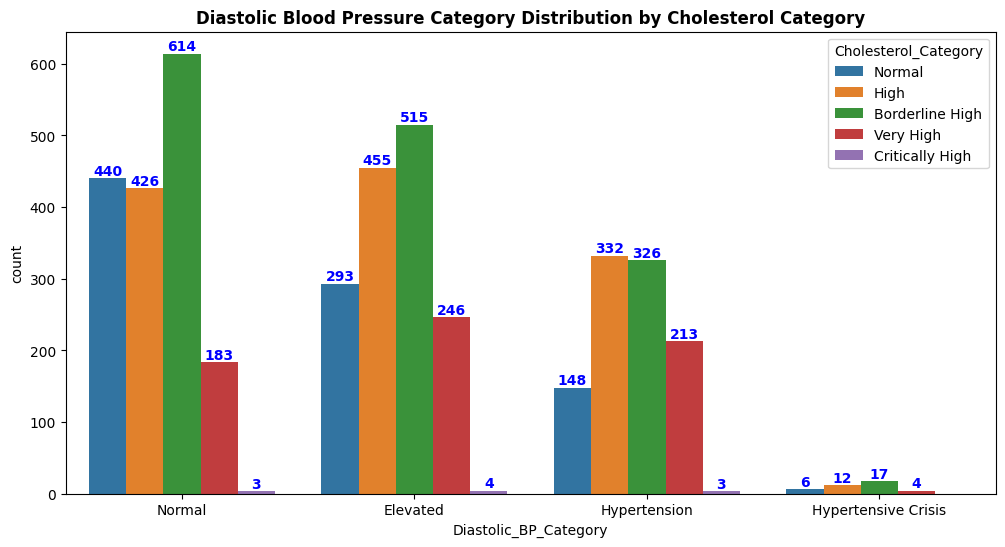

In [217]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "Diastolic_BP_Category",
    order=(df["Diastolic_BP_Category"].value_counts().index),
    hue = "Cholesterol_Category"
)

for container in ax.containers:
    ax.bar_label(container,
                fontweight="bold",
                color = "blue")

plt.title("Diastolic Blood Pressure Category Distribution by Cholesterol Category",fontweight = "bold")
plt.show()

In [219]:
(pd.crosstab(
    df["Diastolic_BP_Category"],
    df["Cholesterol_Category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

Cholesterol_Category,Borderline High,Critically High,High,Normal,Very High
Diastolic_BP_Category,,,,,
Elevated,34.99%,40.0%,37.14%,33.03%,38.08%
Hypertension,22.15%,30.0%,27.1%,16.69%,32.97%
Hypertensive Crisis,1.15%,0.0%,0.98%,0.68%,0.62%
Normal,41.71%,30.0%,34.78%,49.61%,28.33%


In [72]:
#np.set_printoptions(threshold=np.inf)
#print(df["BMI"].unique())

In [64]:
#df["BMI"].value_counts(dropna=False)

In [199]:
df["BMI_Category"].value_counts(dropna=False)

BMI_Category
Healthy Weight        1870
Overweight            1774
High BMI               420
Very High BMI           93
Underweight             57
Extremely High BMI      26
Name: count, dtype: int64

In [198]:
df["BMI_Category"] = np.select(
    [
        df["BMI"] < 18.5,
        (df["BMI"] >= 18.5) & (df["BMI"] < 25),
        (df["BMI"] >= 25) & (df["BMI"] < 30),
        (df["BMI"] >= 30) & (df["BMI"] < 35),
        (df["BMI"] >= 35) & (df["BMI"] < 40),
        df["BMI"] >= 40
    ],
    
    [
        "Underweight",
        "Healthy Weight",
        "Overweight",
        "High BMI",
        "Very High BMI",
        "Extremely High BMI"
    ],
    default = "Not Reported"
)

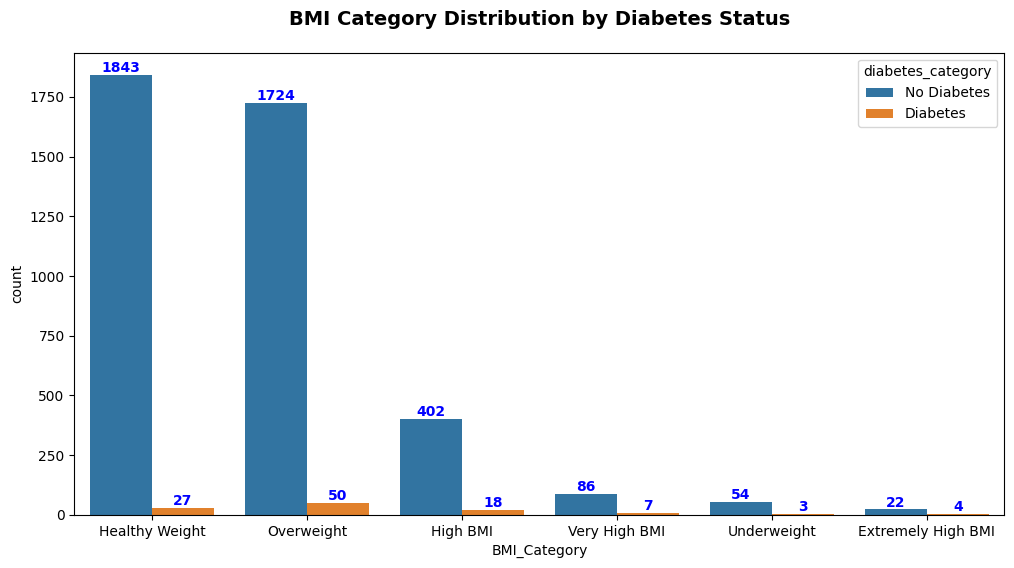

In [220]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "BMI_Category",
    order=(df["BMI_Category"].value_counts().index),
    hue = "diabetes_category"
)

for container in ax.containers:
    ax.bar_label(container,
                fontweight="bold",
                color = "blue")

plt.title("BMI Category Distribution by Diabetes Status",
    fontsize=14,
    pad=20,
    fontweight="bold"
)
plt.show()

In [222]:
(pd.crosstab(
    df["BMI_Category"],
    df["diabetes_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

diabetes_category,Diabetes,No Diabetes
BMI_Category,,
Extremely High BMI,3.67%,0.53%
Healthy Weight,24.77%,44.61%
High BMI,16.51%,9.73%
Overweight,45.87%,41.73%
Underweight,2.75%,1.31%
Very High BMI,6.42%,2.08%


In [73]:
#df["heartRate"].max()

In [61]:
df["heartRate"].unique()

array([ 80.,  95.,  75.,  65.,  85.,  77.,  60.,  79.,  76.,  93.,  72.,
        98.,  64.,  70.,  71.,  62.,  73.,  90.,  96.,  68.,  63.,  88.,
        78.,  83., 100.,  67.,  84.,  57.,  50.,  74.,  86.,  55.,  92.,
        66.,  87., 110.,  81.,  56.,  89.,  82.,  48., 105.,  61.,  54.,
        69.,  52.,  94., 140., 130.,  58., 108., 104.,  91.,  53.,  nan,
       106.,  59.,  51., 102., 107., 112., 125., 103.,  44.,  47.,  45.,
        97., 122., 120.,  99., 115., 143., 101.,  46.])

In [75]:
#df["heartRate"].value_counts(dropna=False)

In [197]:
df["HeartRate_Category"].value_counts(dropna=False)

HeartRate_Category
Normal Heart Rate      3929
Low Heart Rate          206
Elevated Heart Rate      97
High Heart Rate           8
Name: count, dtype: int64

In [196]:
df["HeartRate_Category"] = np.select(
    [
        df["heartRate"] < 60,
        (df["heartRate"] >= 60) & (df["heartRate"] <= 100),
        (df["heartRate"] >= 101) & (df["heartRate"] <= 120),
        df["heartRate"] > 120
    ],
    [
        "Low Heart Rate",
        "Normal Heart Rate",
        "Elevated Heart Rate",
        "High Heart Rate"
    ],
    default="Not Reported"
)

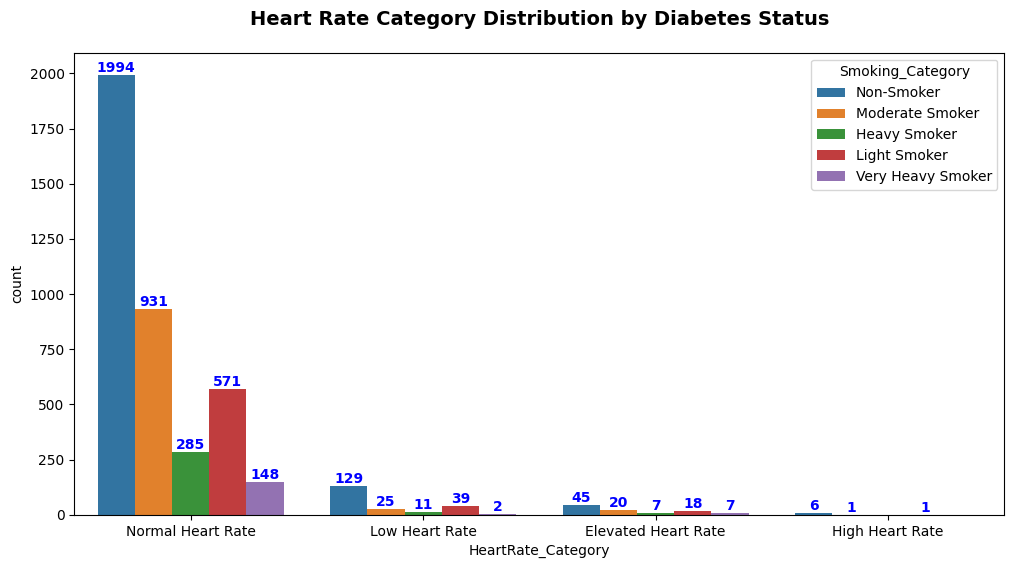

In [224]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "HeartRate_Category",
    order=(df["HeartRate_Category"].value_counts().index),
    hue = "Smoking_Category"
)

for container in ax.containers:
    ax.bar_label(container,
                fontweight="bold",
                color = "blue")

plt.title("Heart Rate Category Distribution by Diabetes Status",
    fontsize=14,
    pad=20,
    fontweight="bold"
)
plt.show()

In [225]:
(pd.crosstab(
    df["HeartRate_Category"],
    df["Smoking_Category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

Smoking_Category,Heavy Smoker,Light Smoker,Moderate Smoker,Non-Smoker,Very Heavy Smoker
HeartRate_Category,,,,,
Elevated Heart Rate,2.31%,2.86%,2.05%,2.07%,4.46%
High Heart Rate,0.0%,0.16%,0.1%,0.28%,0.0%
Low Heart Rate,3.63%,6.2%,2.56%,5.93%,1.27%
Normal Heart Rate,94.06%,90.78%,95.29%,91.72%,94.27%


In [74]:
#df["glucose"].unique()

In [200]:
df["Glucose_Category"] = np.select(
    [
        df["glucose"] < 70,
        (df["glucose"] >= 70) & (df["glucose"] < 100),
        (df["glucose"] >= 100) & (df["glucose"] < 126),
        df["glucose"] >= 126
    ],
    [
        "Low Glucose",
        "Normal Glucose",
        "Prediabetes",
        "Diabetes Range"
    ],
    default="Not Reported"
)

In [201]:
df["Glucose_Category"].value_counts(dropna=False)

Glucose_Category
Normal Glucose    3133
Low Glucose        746
Prediabetes        275
Diabetes Range      86
Name: count, dtype: int64

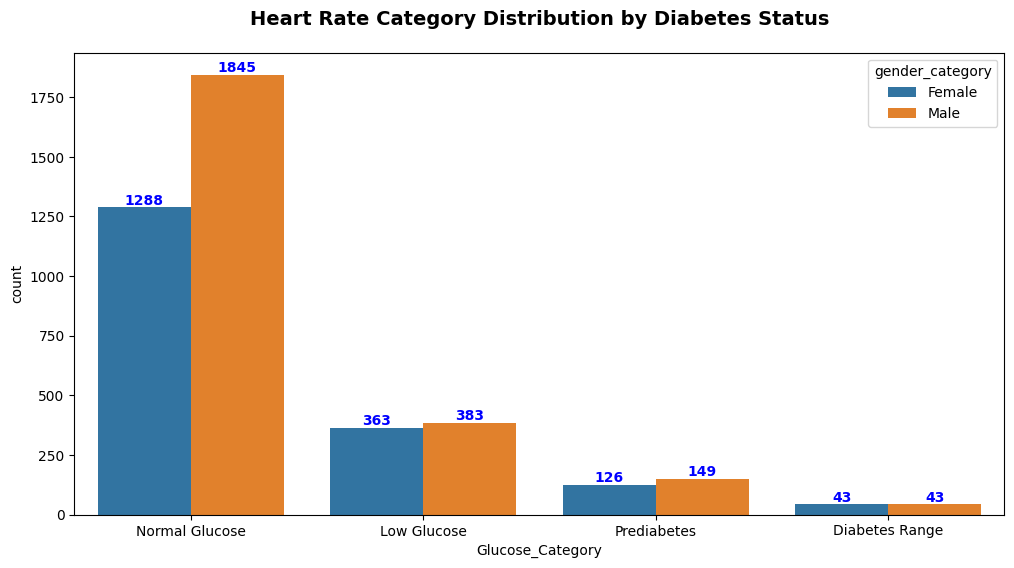

In [227]:
plt.figure(figsize=(12,6))

ax = sns.countplot(
    data = df,
    x = "Glucose_Category",
    order=(df["Glucose_Category"].value_counts().index),
    hue = "gender_category"
)

for container in ax.containers:
    ax.bar_label(container,
                fontweight="bold",
                color = "blue")

plt.title("Heart Rate Category Distribution by Diabetes Status",
    fontsize=14,
    pad=20,
    fontweight="bold"
)
plt.show()

In [228]:
(pd.crosstab(
    df["Glucose_Category"],
    df["gender_category"],
    normalize="columns"
) * 100).round(2).astype(str) + "%"

gender_category,Female,Male
Glucose_Category,,
Diabetes Range,2.36%,1.78%
Low Glucose,19.95%,15.83%
Normal Glucose,70.77%,76.24%
Prediabetes,6.92%,6.16%


In [233]:
print(df.head())
print()
print(df.tail())

   gender  age  education  currentSmoker  cigsPerDay  \
0       1   39        4.0              0         0.0   
1       0   46        2.0              0         0.0   
2       1   48        1.0              1        20.0   
3       0   61        3.0              1        30.0   
4       0   46        3.0              1        23.0   

   Blood Pressure Medications  prevalentStroke  prevalentHyp  diabetes  \
0                         0.0                0             0         0   
1                         0.0                0             0         0   
2                         0.0                0             0         0   
3                         0.0                0             1         0   
4                         0.0                0             0         0   

   Total_Cholesterol  Systolic_BP  Diastolic_BP    BMI  heartRate  glucose  \
0              195.0        106.0          70.0  26.97       80.0     77.0   
1              250.0        121.0          81.0  28.73       9

In [234]:
df.to_csv("Diabetes_Risk_Prediction.csv", index=False)